# Compare EigenMaps vs Cosine Similarity vs Pearson r

Compare three ways to summarize cross-cell-type attribution structure:
1. **EigenMap** — eigenvector decomposition of the importance matrix
2. **Cosine similarity** — per-position cosine between cell-type attribution vectors
3. **Pearson r** — per-position correlation between cell-type attributions

In [1]:
import os, sys, importlib, pathlib
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

for pyc in pathlib.Path('..', '__pycache__').glob('eigen_steering.cpython-*.pyc'):
    pyc.unlink(missing_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cosine
from scipy.stats import pearsonr

import eigen_steering; importlib.reload(eigen_steering)
from eigen_steering import EigenMap, PROMOTER_SEQ, RAND_BARCODE, ENHANCER_LEN

AlphaGenome patches applied (all functional activations -> nn.Module).


CSV sequences: 56978, Attribution maps: 56978
EigenMap: ['K562', 'HepG2'], models={'K562': 'K562_v6_do075', 'HepG2': 'HepG2_v6_do03'}
Loaded 56978 sequences, X shape: torch.Size([56978, 4, 281])
Loaded attributions for ['K562', 'HepG2'] from /grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/genomic_targets/data/deeplift_attributions.npz
Eigendecomposed 56978 sequences (enhancer only, 230bp)


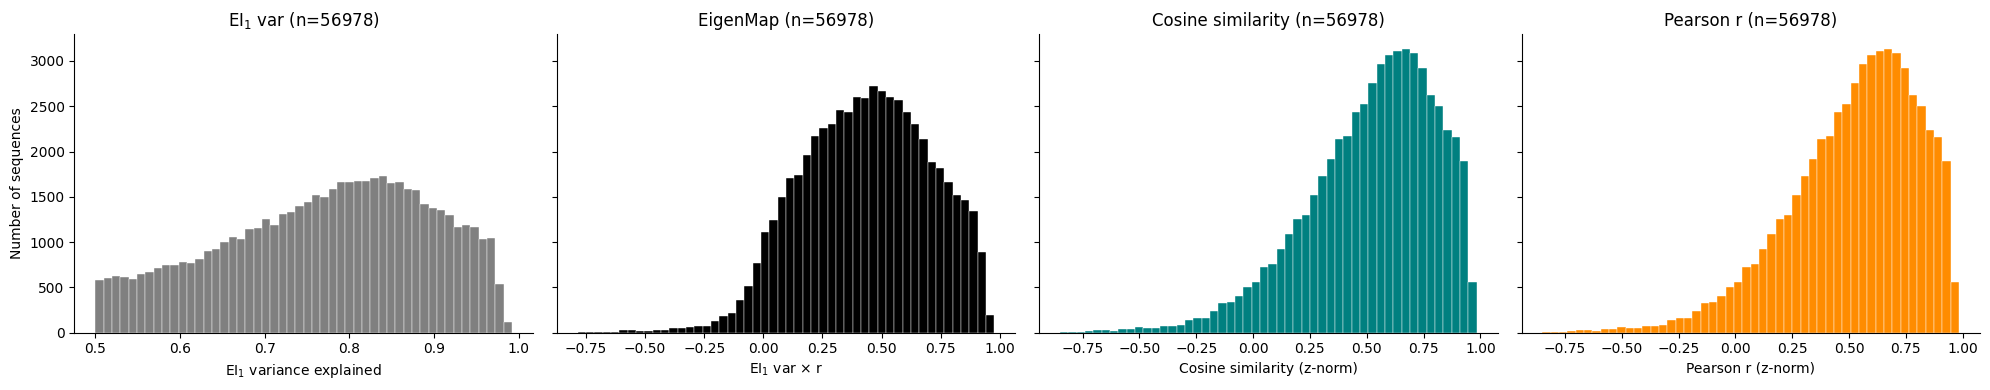

In [2]:
# Load joint library sequences
joint_df = pd.read_csv(
    '/grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/Cell_line_MoCon/'
    'Cross-line_analysis/pred_first/joint_data/joint_library_combined.csv'
)
# Drop NaN sequences — attributions were computed on valid sequences only
joint_df = joint_df.dropna(subset=['sequence']).reset_index(drop=True)

ATTR_PATH = '/grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/genomic_targets/data/deeplift_attributions.npz'
N = np.load(ATTR_PATH, allow_pickle=True)['attr_K562'].shape[0]
print(f"CSV sequences: {len(joint_df)}, Attribution maps: {N}")
assert len(joint_df) >= N, f"CSV has fewer sequences ({len(joint_df)}) than attributions ({N})"

# Use v6 model names (matching the precomputed attributions)
MODEL_NAMES_2 = {
    'K562':  'K562_v6_do075',
    'HepG2': 'HepG2_v6_do03',
}

# Load into EigenMap, load precomputed attributions, eigendecompose
em = EigenMap(model_names=MODEL_NAMES_2, device='cuda')
em.load_sequences(joint_df['sequence'].values[:N].tolist())
em.load_attributions(ATTR_PATH)
em.eigendecompose(enhancer_only=True)

# Z-normalize importance maps per cell type per sequence (matching eigendecompose)
imp_k = em.importance['K562'][:, :ENHANCER_LEN].copy()  # (N, 230)
imp_h = em.importance['HepG2'][:, :ENHANCER_LEN].copy()

std_k = imp_k.std(axis=1, keepdims=True)
std_h = imp_h.std(axis=1, keepdims=True)
std_k[std_k == 0] = 1
std_h[std_h == 0] = 1
imp_k_z = (imp_k - imp_k.mean(axis=1, keepdims=True)) / std_k
imp_h_z = (imp_h - imp_h.mean(axis=1, keepdims=True)) / std_h

# EI_1 var x r (from eigendecompose, already z-normalized internally)
ei1_vxr = np.array([
    r['var_ratio'][0] * np.corrcoef(r['E_scaled'][:, 0], r['E_scaled'][:, 1])[0, 1]
    for r in em.eigen_results
])

# EI_1 var alone
ei1_var = np.array([r['var_ratio'][0] for r in em.eigen_results])

# Cosine similarity (on z-normalized maps)
norms_k = np.linalg.norm(imp_k_z, axis=1)
norms_h = np.linalg.norm(imp_h_z, axis=1)
cos_vals = (imp_k_z * imp_h_z).sum(axis=1) / (norms_k * norms_h + 1e-12)

# Pearson r (on z-normalized maps — equivalent to raw, but consistent)
k_c = imp_k_z - imp_k_z.mean(axis=1, keepdims=True)
h_c = imp_h_z - imp_h_z.mean(axis=1, keepdims=True)
pear_vals = (k_c * h_c).sum(axis=1) / (
    np.linalg.norm(k_c, axis=1) * np.linalg.norm(h_c, axis=1) + 1e-12
)

# Plot distributions
fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)

axes[0].hist(ei1_var, bins=50, color='gray', edgecolor='white', lw=0.3)
axes[0].set_xlabel('EI$_1$ variance explained')
axes[0].set_ylabel('Number of sequences')
axes[0].set_title(f'EI$_1$ var (n={N})')

axes[1].hist(ei1_vxr, bins=50, color='black', edgecolor='white', lw=0.3)
axes[1].set_xlabel('EI$_1$ var $\\times$ r')
axes[1].set_title(f'EigenMap (n={N})')

axes[2].hist(cos_vals, bins=50, color='teal', edgecolor='white', lw=0.3)
axes[2].set_xlabel('Cosine similarity (z-norm)')
axes[2].set_title(f'Cosine similarity (n={N})')

axes[3].hist(pear_vals, bins=50, color='darkorange', edgecolor='white', lw=0.3)
axes[3].set_xlabel('Pearson r (z-norm)')
axes[3].set_title(f'Pearson r (n={N})')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

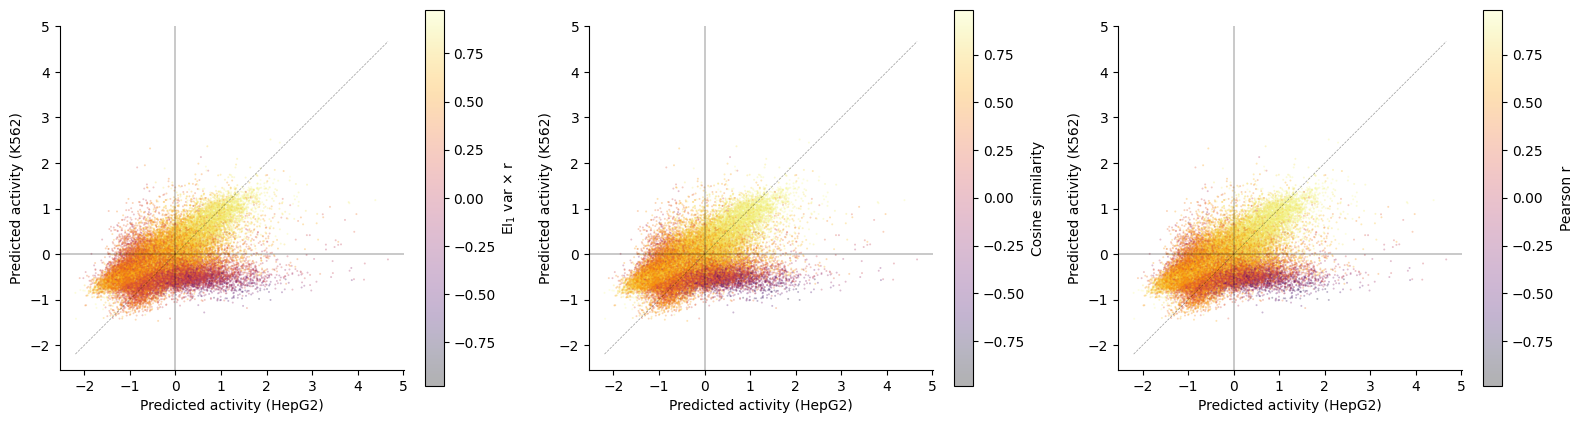

In [3]:
# Predicted vs predicted scatter colored by each similarity metric
pred_k = em.predictions['K562']
pred_h = em.predictions['HepG2']

metrics = [
    ('EI$_1$ var $\\times$ r', ei1_vxr, 'inferno'),
    ('Cosine similarity', cos_vals, 'inferno'),
    ('Pearson r', pear_vals, 'inferno'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (label, vals, cmap) in zip(axes, metrics):
    vmax = np.nanmax(np.abs(vals))
    sc = ax.scatter(pred_h, pred_k, c=vals, cmap=cmap, vmin=-vmax, vmax=vmax,
                    s=2, alpha=0.3, edgecolors='none', rasterized=True)
    cbar = fig.colorbar(sc, ax=ax, shrink=0.8)
    cbar.set_label(label)
    lims = [min(pred_k.min(), pred_h.min()), max(pred_k.max(), pred_h.max())]
    ax.plot(lims, lims, 'k--', lw=0.5, alpha=0.4)
    ax.axhline(0, color='k', lw=0.3)
    ax.axvline(0, color='k', lw=0.3)
    ax.set_xlabel('Predicted activity (HepG2)')
    ax.set_ylabel('Predicted activity (K562)')
    ax.set_aspect('equal')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

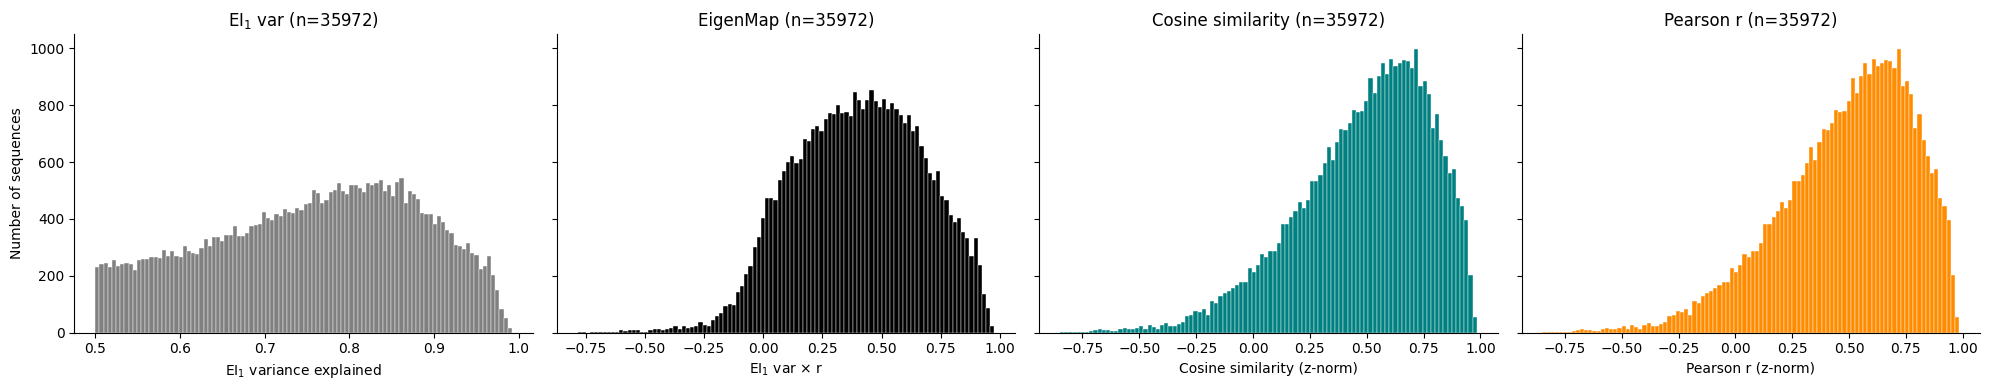

In [5]:
# Distributions — only K562/HepG2-named sequences (no WTC11/controls)
names = joint_df['name'].values[:N]
mask = np.array([str(n).startswith('K562') or str(n).startswith('HepG2') for n in names])
n_sub = mask.sum()

fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)

axes[0].hist(ei1_var[mask], bins=100, color='gray', edgecolor='white', lw=0.3)
axes[0].set_xlabel('EI$_1$ variance explained')
axes[0].set_ylabel('Number of sequences')
axes[0].set_title(f'EI$_1$ var (n={n_sub})')

axes[1].hist(ei1_vxr[mask], bins=100, color='black', edgecolor='white', lw=0.3)
axes[1].set_xlabel('EI$_1$ var $\\times$ r')
axes[1].set_title(f'EigenMap (n={n_sub})')

axes[2].hist(cos_vals[mask], bins=100, color='teal', edgecolor='white', lw=0.3)
axes[2].set_xlabel('Cosine similarity (z-norm)')
axes[2].set_title(f'Cosine similarity (n={n_sub})')

axes[3].hist(pear_vals[mask], bins=100, color='darkorange', edgecolor='white', lw=0.3)
axes[3].set_xlabel('Pearson r (z-norm)')
axes[3].set_title(f'Pearson r (n={n_sub})')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

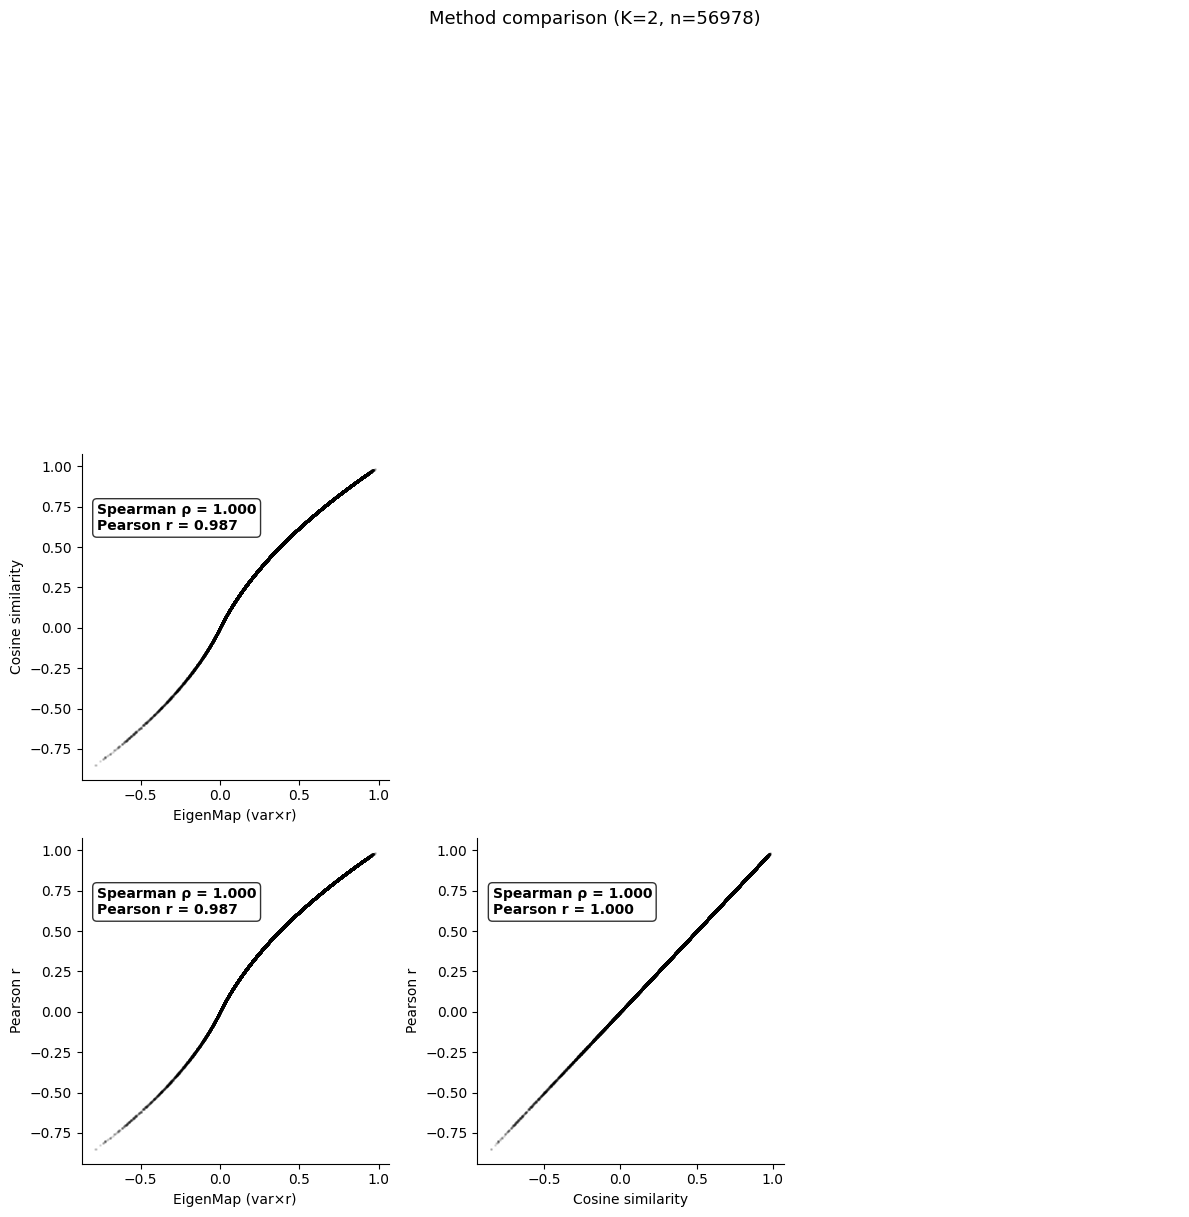

In [14]:
# Lower-triangle scatter: pairwise method comparison (K=2)
from scipy.stats import spearmanr

methods = {
    'EigenMap (var×r)': ei1_vxr,
    'Cosine similarity': cos_vals,
    'Pearson r': pear_vals,
}
method_names = list(methods.keys())
method_vals = list(methods.values())
n_methods = len(method_names)

fig, axes = plt.subplots(n_methods, n_methods, figsize=(12, 12))

for i in range(n_methods):
    for j in range(n_methods):
        ax = axes[i, j]
        if j < i:
            # Lower triangle: scatter plot
            rho, _ = spearmanr(method_vals[j], method_vals[i])
            r_pear = np.corrcoef(method_vals[j], method_vals[i])[0, 1]
            ax.scatter(method_vals[j], method_vals[i], s=1, alpha=0.1,
                       color='black', rasterized=True)
            ax.annotate(f'Spearman ρ = {rho:.3f}\nPearson r = {r_pear:.3f}',
                        xy=(0.05, 0.85), xycoords='axes fraction',
                        fontsize=10, fontweight='bold', va='top',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
            ax.set_xlabel(method_names[j], fontsize=10)
            ax.set_ylabel(method_names[i], fontsize=10)
        else:
            ax.axis('off')

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.suptitle(f'Method comparison (K=2, n={N})', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

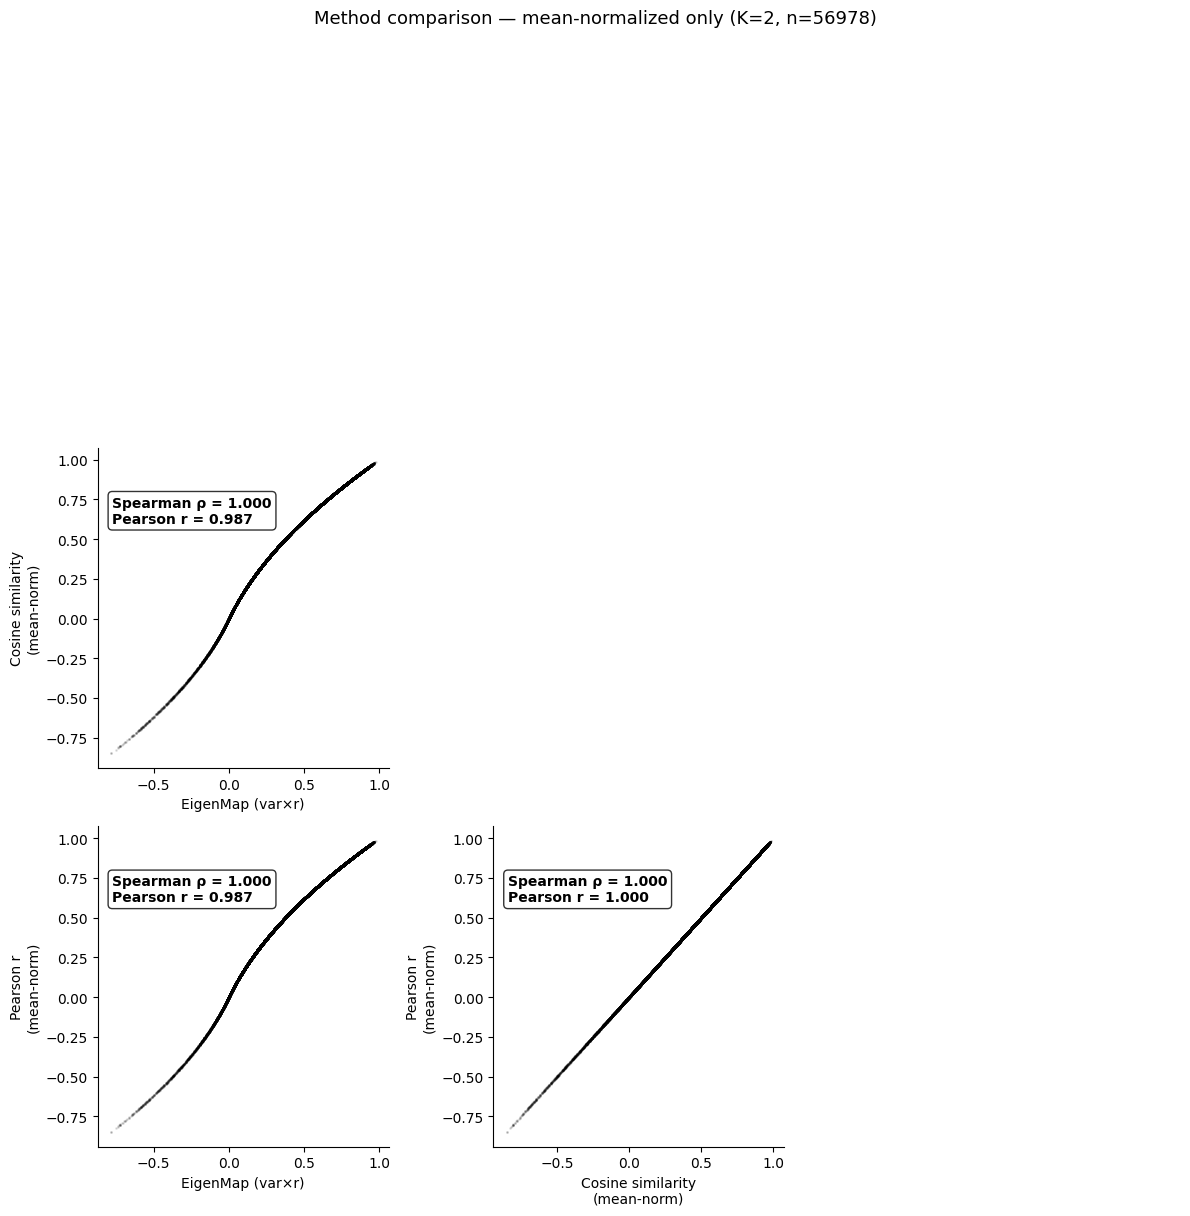

In [16]:
# Lower-triangle scatter: mean-normalized only (no std scaling)
from scipy.stats import spearmanr

# Mean-normalize importance maps (center only, no z-score)
imp_k_m = imp_k - imp_k.mean(axis=1, keepdims=True)
imp_h_m = imp_h - imp_h.mean(axis=1, keepdims=True)

# Cosine similarity (mean-normalized)
norms_k_m = np.linalg.norm(imp_k_m, axis=1)
norms_h_m = np.linalg.norm(imp_h_m, axis=1)
cos_vals_m = (imp_k_m * imp_h_m).sum(axis=1) / (norms_k_m * norms_h_m + 1e-12)

# Pearson r (mean-normalized)
k_c_m = imp_k_m - imp_k_m.mean(axis=1, keepdims=True)
h_c_m = imp_h_m - imp_h_m.mean(axis=1, keepdims=True)
pear_vals_m = (k_c_m * h_c_m).sum(axis=1) / (
    np.linalg.norm(k_c_m, axis=1) * np.linalg.norm(h_c_m, axis=1) + 1e-12
)

methods_m = {
    'EigenMap (var×r)': ei1_vxr,
    'Cosine similarity\n(mean-norm)': cos_vals_m,
    'Pearson r\n(mean-norm)': pear_vals_m,
}
method_names_m = list(methods_m.keys())
method_vals_m = list(methods_m.values())
n_methods_m = len(method_names_m)

fig, axes = plt.subplots(n_methods_m, n_methods_m, figsize=(12, 12))

for i in range(n_methods_m):
    for j in range(n_methods_m):
        ax = axes[i, j]
        if j < i:
            rho, _ = spearmanr(method_vals_m[j], method_vals_m[i])
            r_pear = np.corrcoef(method_vals_m[j], method_vals_m[i])[0, 1]
            ax.scatter(method_vals_m[j], method_vals_m[i], s=1, alpha=0.1,
                       color='black', rasterized=True)
            ax.annotate(f'Spearman ρ = {rho:.3f}\nPearson r = {r_pear:.3f}',
                        xy=(0.05, 0.85), xycoords='axes fraction',
                        fontsize=10, fontweight='bold', va='top',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
            ax.set_xlabel(method_names_m[j], fontsize=10)
            ax.set_ylabel(method_names_m[i], fontsize=10)
        else:
            ax.axis('off')

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.suptitle(f'Method comparison — mean-normalized only (K=2, n={N})', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## K=3: K562 + HepG2 + WTC11

56974 sequences with K562 + HepG2 + WTC11 data
EigenMap: ['K562', 'HepG2', 'WTC11'], models={'K562': 'K562_v6_do075', 'HepG2': 'HepG2_v6_do03', 'WTC11': 'WTC11_v6_do075'}
Loaded 56974 sequences, X shape: torch.Size([56974, 4, 281])
Loaded attributions for ['K562', 'HepG2', 'WTC11']
Eigendecomposed 56974 sequences (enhancer only, 230bp)


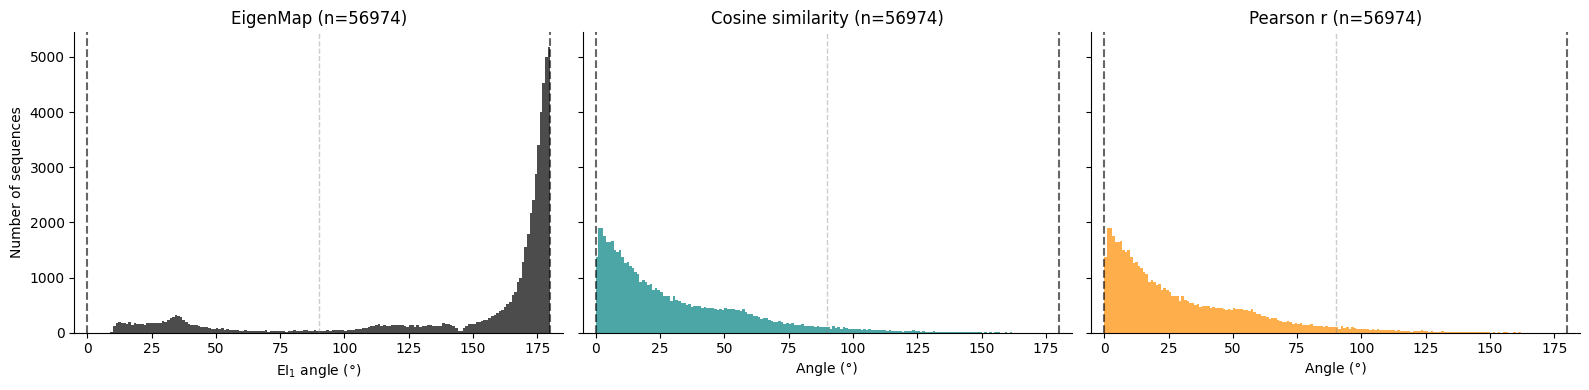

In [ ]:
# K=3 comparison: K562 + HepG2 + WTC11
from scipy.spatial.distance import cosine as cosine_dist
from scipy.stats import pearsonr as _pearsonr

MODEL_NAMES_3 = {
    'K562':  'K562_v6_do075',
    'HepG2': 'HepG2_v6_do03',
    'WTC11': 'WTC11_v6_do075',
}

REPO = '/grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra'
DATA_CSV = os.path.join(REPO, 'data', 'joint_library_combined.csv')
ATTR_PATH_3 = os.path.join(REPO, 'genomic_targets', 'data', 'deeplift_attributions.npz')

# Load and filter to sequences with all 3 cell types measured
df3 = pd.read_csv(DATA_CSV)
df3 = df3.dropna(subset=['sequence', 'K562_log2FC', 'HepG2_log2FC', 'WTC11_log2FC']).reset_index(drop=True)
print(f'{len(df3)} sequences with K562 + HepG2 + WTC11 data')

# Load into EigenMap
em3 = EigenMap(model_names=MODEL_NAMES_3, device='cuda')
em3.load_from_dataframe(df3, seq_col='sequence')
em3.set_actual({ct: df3[f'{ct}_log2FC'].values for ct in MODEL_NAMES_3})

# Load attributions with index alignment
df_full = pd.read_csv(DATA_CSV)
seq_valid_idx = df_full['sequence'].notna()
n_seq_valid = seq_valid_idx.sum()
full_valid_idx = df_full[['sequence','K562_log2FC','HepG2_log2FC','WTC11_log2FC']].notna().all(axis=1)
keep_mask = full_valid_idx[seq_valid_idx].values
del df_full

raw = np.load(ATTR_PATH_3, allow_pickle=False)
ohe3 = em3.X.numpy()
for ct in MODEL_NAMES_3:
    arr = raw[f'attr_{ct}'][:n_seq_valid]
    hyp = arr[keep_mask]
    em3.attr_hyp[ct] = hyp
    em3.attr[ct] = hyp * ohe3
    em3.importance[ct] = em3.attr[ct].sum(axis=1)
    if f'predictions_{ct}' in raw:
        em3.predictions[ct] = raw[f'predictions_{ct}'][:n_seq_valid][keep_mask]

print(f'Loaded attributions for {list(MODEL_NAMES_3.keys())}')

# Eigendecompose
em3.eigendecompose(enhancer_only=True)
N3 = len(em3.eigen_results)

# --- Shared direction ---
shared_dir = np.array([1, 1, 1]) / np.sqrt(3)

# --- EigenMap: raw angle of EI_1 to shared direction (0–180°) ---
ei1_vecs = np.array([r['eigenvectors'][:, 0] for r in em3.eigen_results])  # (N, 3)
cos_ei = np.clip(ei1_vecs @ shared_dir, -1, 1)
ei1_angles = np.degrees(np.arccos(cos_ei))

# --- Cosine similarity: pairwise vector angle to shared direction (0–180°) ---
cts = list(MODEL_NAMES_3.keys())
imp_3 = {}
for ct in cts:
    v = em3.importance[ct][:, :ENHANCER_LEN].copy()
    s = v.std(axis=1, keepdims=True)
    s[s == 0] = 1
    imp_3[ct] = (v - v.mean(axis=1, keepdims=True)) / s

pairs = [(0, 1), (0, 2), (1, 2)]
cos_pairwise = np.zeros((N3, 3))
pear_pairwise = np.zeros((N3, 3))
for pi, (a, b) in enumerate(pairs):
    for i in range(N3):
        cos_pairwise[i, pi] = 1 - cosine_dist(imp_3[cts[a]][i], imp_3[cts[b]][i])
        pear_pairwise[i, pi] = _pearsonr(imp_3[cts[a]][i], imp_3[cts[b]][i])[0]

cos_raw = np.clip(cos_pairwise @ shared_dir / (np.linalg.norm(cos_pairwise, axis=1) + 1e-12), -1, 1)
cos_angles = np.degrees(np.arccos(cos_raw))

pear_raw = np.clip(pear_pairwise @ shared_dir / (np.linalg.norm(pear_pairwise, axis=1) + 1e-12), -1, 1)
pear_angles = np.degrees(np.arccos(pear_raw))

# --- Plot: raw angle distributions (0–180°) ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
bins_angle = np.linspace(0, 180, 181)

for ax in axes:
    ax.axvline(0, color='black', alpha=0.6, linewidth=1.5, linestyle='--')
    ax.axvline(90, color='gray', alpha=0.4, linewidth=1, linestyle='--')
    ax.axvline(180, color='black', alpha=0.6, linewidth=1.5, linestyle='--')

axes[0].hist(ei1_angles, bins=bins_angle, color='black', edgecolor='none', alpha=0.7)
axes[0].set_xlabel('EI$_1$ angle (°)')
axes[0].set_ylabel('Number of sequences')
axes[0].set_title(f'EigenMap (n={N3})')

axes[1].hist(cos_angles, bins=bins_angle, color='teal', edgecolor='none', alpha=0.7)
axes[1].set_xlabel('Angle (°)')
axes[1].set_title(f'Cosine similarity (n={N3})')

axes[2].hist(pear_angles, bins=bins_angle, color='darkorange', edgecolor='none', alpha=0.7)
axes[2].set_xlabel('Angle (°)')
axes[2].set_title(f'Pearson r (n={N3})')

for ax in axes:
    ax.set_xlim(-5, 185)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

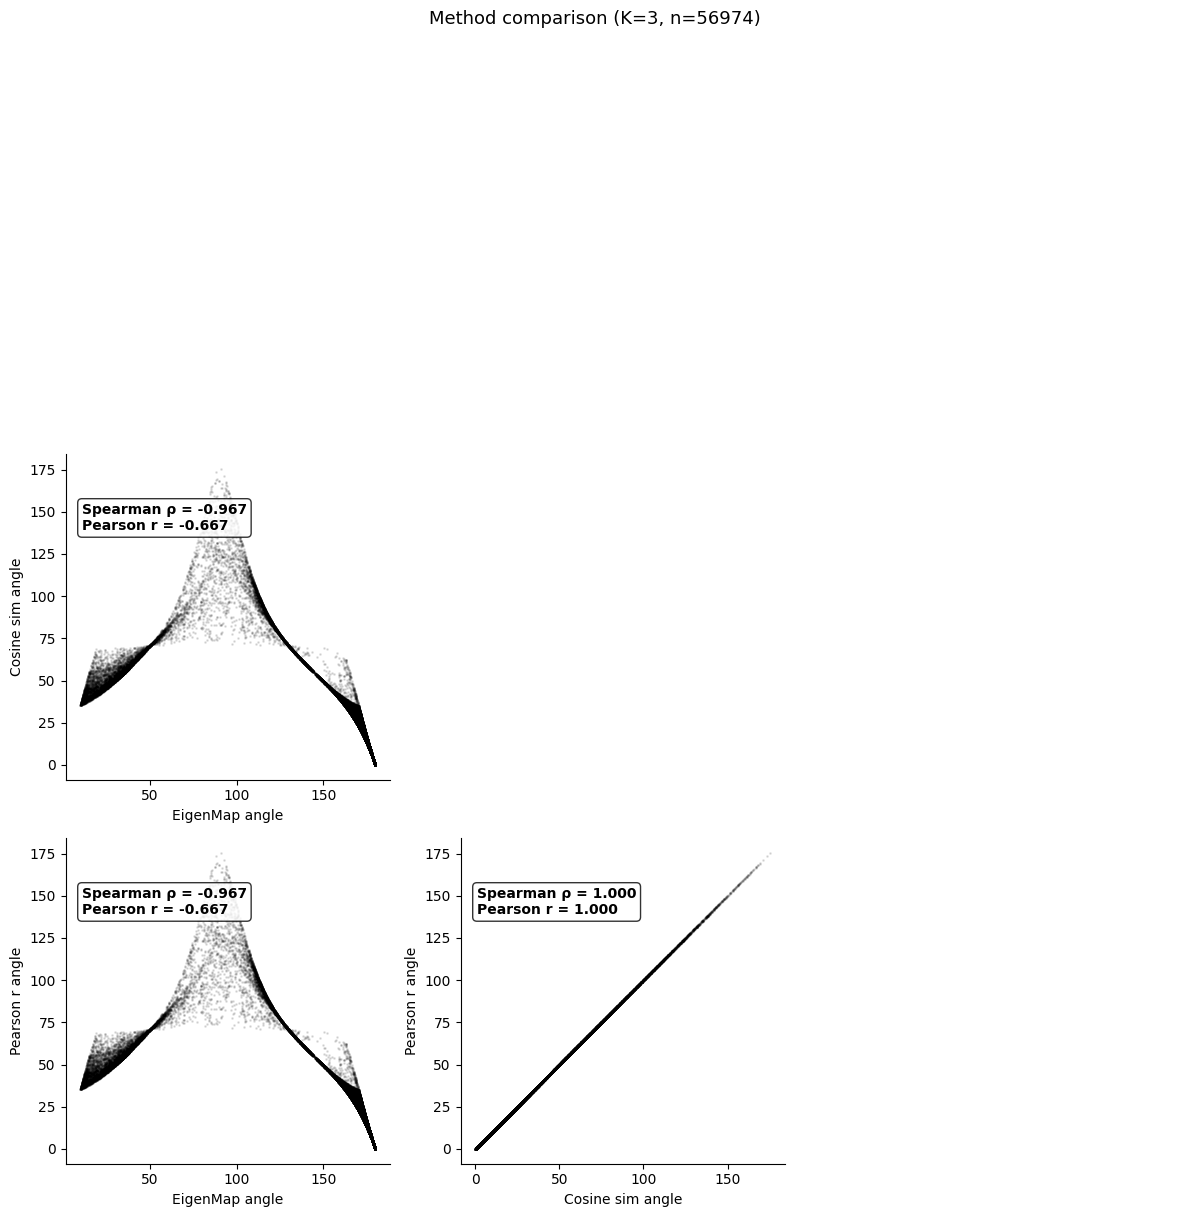

In [17]:
# Lower-triangle scatter: pairwise method comparison (K=3)
from scipy.stats import spearmanr

methods_3 = {
    'EigenMap angle': ei1_angles,
    'Cosine sim angle': cos_angles,
    'Pearson r angle': pear_angles,
}
method_names_3 = list(methods_3.keys())
method_vals_3 = list(methods_3.values())
n_methods_3 = len(method_names_3)

fig, axes = plt.subplots(n_methods_3, n_methods_3, figsize=(12, 12))

for i in range(n_methods_3):
    for j in range(n_methods_3):
        ax = axes[i, j]
        if j < i:
            rho, _ = spearmanr(method_vals_3[j], method_vals_3[i])
            r_pear = np.corrcoef(method_vals_3[j], method_vals_3[i])[0, 1]
            ax.scatter(method_vals_3[j], method_vals_3[i], s=1, alpha=0.1,
                       color='black', rasterized=True)
            ax.annotate(f'Spearman ρ = {rho:.3f}\nPearson r = {r_pear:.3f}',
                        xy=(0.05, 0.85), xycoords='axes fraction',
                        fontsize=10, fontweight='bold', va='top',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
            ax.set_xlabel(method_names_3[j], fontsize=10)
            ax.set_ylabel(method_names_3[i], fontsize=10)
        else:
            ax.axis('off')

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.suptitle(f'Method comparison (K=3, n={N3})', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [18]:
# EigenMaps = PCA on importance maps = eigendecomposition of correlation matrix
# The correlation matrix is FULLY determined by pairwise Pearson r values.
# So pairwise Pearson r contains ALL the information EigenMaps uses.

print("=== Proof: EigenMaps is just PCA on the pairwise correlation matrix ===\n")

# Pick a few example sequences
for ex_idx in [0, 100, 1000]:
    r = em3.eigen_results[ex_idx]
    
    # 1. EigenMap's covariance matrix (computed internally)
    C_eigenmap = r['cov']
    
    # 2. Rebuild it from pairwise Pearson r values alone
    #    For z-normalized data: C_ij = Pearson_r(I_i, I_j)
    C_from_pearson = np.zeros((3, 3))
    for i, ct_i in enumerate(cts):
        for j, ct_j in enumerate(cts):
            if i == j:
                C_from_pearson[i, j] = C_eigenmap[i, i]  # variance (diagonal)
            else:
                C_from_pearson[i, j] = np.corrcoef(
                    imp_3[ct_i][ex_idx], imp_3[ct_j][ex_idx]
                )[0, 1] * np.sqrt(C_eigenmap[i, i] * C_eigenmap[j, j])
    
    # 3. Eigendecompose the reconstructed matrix
    eigvals_recon, eigvecs_recon = np.linalg.eigh(C_from_pearson)
    # Sort descending
    order = np.argsort(eigvals_recon)[::-1]
    eigvals_recon = eigvals_recon[order]
    eigvecs_recon = eigvecs_recon[:, order]
    
    # Align signs (eigenvectors have arbitrary sign)
    for k in range(3):
        if np.dot(eigvecs_recon[:, k], r['eigenvectors'][:, k]) < 0:
            eigvecs_recon[:, k] *= -1
    
    print(f"Sequence {ex_idx}:")
    print(f"  EigenMap eigvec_1:     {r['eigenvectors'][:, 0]}")
    print(f"  From pairwise r:      {eigvecs_recon[:, 0]}")
    print(f"  Max difference:       {np.max(np.abs(r['eigenvectors'] - eigvecs_recon)):.2e}")
    print()

print("─" * 60)
print()
print("Conclusion: EigenMaps IS eigendecomposition of the pairwise")
print("correlation matrix. Pairwise Pearson r (= cosine sim on")
print("z-normed data) contains ALL the information.")
print()
print("What EigenMaps actually gives you:")
print("  1. A packaging of PCA-on-attributions for genomics")
print("  2. The eigen-interaction LOGOS (position-level A/C/G/T maps)")
print("     — these are just E @ V, a linear combo of attributions")
print("  3. You could compute the same logos from pairwise r + SVD")
print()
print("The scalar summary (var×r, angle, concordance) is redundant")
print("with pairwise cosine similarity / Pearson r.")

=== Proof: EigenMaps is just PCA on the pairwise correlation matrix ===

Sequence 0:
  EigenMap eigvec_1:     [-0.64486796 -0.64605665 -0.40835792]
  From pairwise r:      [-0.6448679  -0.64605667 -0.40835789]
  Max difference:       3.55e-07

Sequence 100:
  EigenMap eigvec_1:     [-0.5710979  -0.5756322  -0.58523047]
  From pairwise r:      [-0.57109788 -0.57563223 -0.58523051]
  Max difference:       1.06e-06

Sequence 1000:
  EigenMap eigvec_1:     [-0.62358063 -0.521084   -0.5827681 ]
  From pairwise r:      [-0.62358063 -0.52108406 -0.58276806]
  Max difference:       1.79e-07

────────────────────────────────────────────────────────────

Conclusion: EigenMaps IS eigendecomposition of the pairwise
correlation matrix. Pairwise Pearson r (= cosine sim on
z-normed data) contains ALL the information.

What EigenMaps actually gives you:
  1. A packaging of PCA-on-attributions for genomics
  2. The eigen-interaction LOGOS (position-level A/C/G/T maps)
     — these are just E @ V, a lin